In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

In [10]:
df = pd.read_csv('E:/Courses/DS/Dataset/Cardiovascular_Disease.csv')
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


#### Data Cleaning

In [11]:
# convert age
age_data = df['age']//365
df['age'] = age_data

In [12]:
sns.boxplot(df[['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']])
plt.close()

<Axes: >

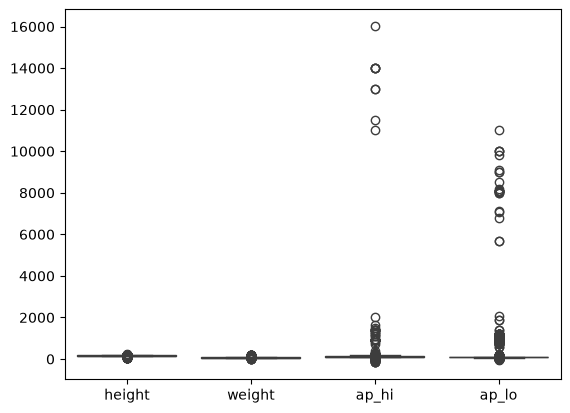

In [13]:
sns.boxplot(df[['height', 'weight', 'ap_hi', 'ap_lo']])

In [14]:
columns = ['age', 'height', 'weight', 'ap_hi', 'ap_lo']

for col in columns:
    print(col)
    print('-'*20)
    min_val = df[col].min()
    max_val = df[col].max()
    print(min_val)
    print(max_val)
    print('\n')

age
--------------------
29
64


height
--------------------
55
250


weight
--------------------
10.0
200.0


ap_hi
--------------------
-150
16020


ap_lo
--------------------
-70
11000




In [15]:
# height = 125 - 200
# weight = 40 - 120
# ap_hi = 100 - 200
# ap_lo = 50 - 90

data_filter = df[(df['height'].between(125, 200)) & 
                (df['weight'].between(40, 120)) & 
                (df['ap_hi'].between(100, 200)) & 
                (df['ap_lo'].between(50, 90))
    ]
df = data_filter

In [16]:
df

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,50,2,168,62.0,110,80,1,1,0,0,1,0
1,1,55,1,156,85.0,140,90,3,1,0,0,1,1
2,2,51,1,165,64.0,130,70,3,1,0,0,0,1
4,4,47,1,156,56.0,100,60,1,1,0,0,0,0
5,8,60,1,151,67.0,120,80,2,2,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69994,99992,57,1,165,80.0,150,80,1,1,0,0,1,1
69995,99993,52,2,168,76.0,120,80,1,1,1,0,1,0
69997,99996,52,2,183,105.0,180,90,3,1,0,1,0,1
69998,99998,61,1,163,72.0,135,80,1,2,0,0,0,1


## Feature and Target

In [17]:
features = ['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']
target = 'cardio'

In [18]:
X = df[features]
Y = df[target]

## Train and Test

In [19]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42, stratify=Y
)

## Feature Scaling

In [20]:
scaler = StandardScaler()

In [21]:
X_train_scale = scaler.fit_transform(X_train)
X_test_scale = scaler.transform(X_test)

## Define Model

In [22]:
model = LogisticRegression(
    solver = 'lbfgs',
    class_weight='balanced',
    random_state=42
)

In [23]:
model.fit(X_train_scale, Y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default

In [24]:
Y_pred = model.predict(X_test_scale)

## metrics

In [25]:
'''
macro_avg = val1 + val2 + val3 + ... + valn / n
weighted_avg = val1 * sup1 + val2 * sup2 + val3 * sup3 + ... + val.n * sup.n / total_support

# macro
(0.79 + 0.64)/2

# wei_avg
((0.79 * 6554) + (0.64 * 5860))/12414
'''

cr = classification_report(Y_test, Y_pred)
cm = confusion_matrix(Y_test, Y_pred)

In [26]:
print(cr)

              precision    recall  f1-score   support

           0       0.72      0.75      0.74      6554
           1       0.71      0.68      0.69      5860

    accuracy                           0.72     12414
   macro avg       0.72      0.71      0.71     12414
weighted avg       0.72      0.72      0.72     12414



In [27]:
print(cm)

[[4933 1621]
 [1896 3964]]


## Visualization

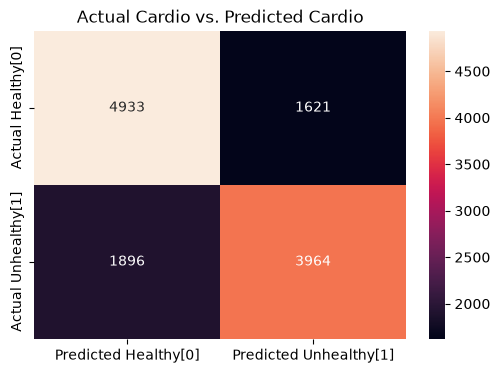

In [28]:
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='1.0f', xticklabels = ['Predicted Healthy[0]', 'Predicted Unhealthy[1]'],
           yticklabels = ['Actual Healthy[0]', 'Actual Unhealthy[1]'])
plt.title('Actual Cardio vs. Predicted Cardio')
plt.show()

## New Data Prediction

In [29]:
# (df['height'].between(125, 200)) & 
# (df['weight'].between(40, 120)) & 
# (df['ap_hi'].between(100, 200)) & 
# (df['ap_lo'].between(50, 90))
data = {
    'age': [30, 40, 29], 
    'gender': [1, 2, 1], 
    'height': [130, 140, 124], 
    'weight': [50, 60, 55], 
    'ap_hi': [130, 140, 120], 
    'ap_lo': [90, 80, 70], 
    'cholesterol': [1, 2, 3], 
    'gluc': [3, 2, 1], 
    'smoke': [1, 0, 0], 
    'alco': [1, 1, 1], 
    'active': [0, 1, 0]
}

In [30]:
X_data = pd.DataFrame(data)
X_data_scale = scaler.transform(X_data)
X_pred = model.predict(X_data_scale)

In [31]:
X_data['cardio_pred'] = X_pred

In [32]:
X_data

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio_pred
0,30,1,130,50,130,90,1,3,1,1,0,0
1,40,2,140,60,140,80,2,2,0,1,1,1
2,29,1,124,55,120,70,3,1,0,1,0,0
